In [69]:
%reload_ext watermark
%watermark -v -p pandas,numpy,geopandas,libpysal,esda,spreg,contextily,splot,scipy,matplotlib

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

pandas    : 3.0.1
numpy     : 2.4.2
geopandas : 1.1.2
libpysal  : 4.14.1
esda      : 2.8.1
spreg     : 1.8.5
contextily: 1.7.0
splot     : 1.1.7
scipy     : 1.17.1
matplotlib: 3.10.8



In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import seaborn as sns
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
from spreg import OLS, ML_Error, ML_Lag, GM_Error, GM_Lag
from scipy import stats
from shapely.geometry import Point
from splot.esda import moran_scatterplot, plot_moran
import contextily as ctx
from matplotlib.ticker import FuncFormatter
import pyproj
from libpysal.weights import lag_spatial
from scipy.stats import norm
from mgwr.gwr import GWR,MGWR
from mgwr.sel_bw import Sel_BW
import libpysal as ps 
from libpysal.weights import Queen
from esda.moran import Moran
import statsmodels.api as sm

In [71]:
df = pd.read_csv(r'Data/listings.csv')

In [72]:
cols = [
    'id', 'latitude', 'longitude', 'price',
    'accommodates', 'beds', 'bathrooms', 'room_type',
    'review_scores_rating', 'host_since',
    'host_is_superhost',
    'host_response_rate', 'calculated_host_listings_count',
    'number_of_reviews_ltm', 'availability_365'
]
df_clean = df[cols].copy()
df_clean.head(5)

,id,latitude,longitude,price,accommodates,beds,bathrooms,room_type,review_scores_rating,host_since,host_is_superhost,host_response_rate,calculated_host_listings_count,number_of_reviews_ltm,availability_365
0,15420,55.957590,-3.188050,$155.00,2,1.0,1.0,Entire home/apt,4.98,2009-12-06,t,100%,1,65,164
1,24288,55.944983,-3.185293,$98.00,4,2.0,1.5,Entire home/apt,4.64,2009-10-17,f,100%,1,55,157
2,38628,55.942150,-3.096400,$117.00,2,2.0,1.5,Entire home/apt,4.68,2010-07-13,f,100%,1,2,318
3,44552,55.966120,-3.171840,$75.00,2,1.0,1.0,Private room,4.77,2010-08-09,t,100%,1,16,19
4,54188,55.942170,-3.208630,$378.00,6,2.0,1.5,Entire home/apt,4.61,2010-10-05,f,100%,3,0,287


In [73]:
print(df_clean.dtypes)

id                                  int64
latitude                          float64
longitude                         float64
price                                 str
accommodates                        int64
beds                              float64
bathrooms                         float64
room_type                             str
review_scores_rating              float64
host_since                            str
host_is_superhost                     str
host_response_rate                    str
calculated_host_listings_count      int64
number_of_reviews_ltm               int64
availability_365                    int64
dtype: object


In [74]:
## Clean price
df_clean['price'] = df_clean['price'].replace(r'[\$,]', '', regex=True).astype(float)
## Clean calculated_host_listings_count
df_clean.rename(columns={'calculated_host_listings_count' : 'host_listings'}, inplace=True)
## Clean number_of_reviews_ltm
df_clean.rename(columns={'number_of_reviews_ltm' : 'number_of_reviews'}, inplace=True)
## Clean host_since
df_clean['host_since'] = pd.to_datetime(df_clean['host_since'], format='%Y-%m-%d')
df_clean['host_years'] = ((pd.Timestamp.today() - df_clean['host_since']).dt.days / 365).astype(float)
df_clean = df_clean.drop(columns=['host_since'])
## Clean host_is_superhost
df_clean['is_superhost'] = (df_clean['host_is_superhost'] == 't').astype(int)
df_clean = df_clean.drop(columns=['host_is_superhost'])
## Clean host_response_rate
df_clean['host_response_rate'] = df_clean['host_response_rate'].replace(r'[\%,]', '', regex=True).astype(float)
## Clean room_type
room_dummies = pd.get_dummies(df_clean['room_type'], prefix='room', drop_first=False)
if 'room_Entire home/apt' in room_dummies.columns:
    room_dummies = room_dummies.drop(columns='room_Entire home/apt')
df_clean = pd.concat([df_clean, room_dummies], axis=1)
df_clean.shape

(4936, 18)

In [75]:
## Drop missing values
key_cols = ['price', 'latitude', 'longitude', 'accommodates',
            'beds', 'bathrooms', 'review_scores_rating',
            'host_response_rate', 'host_listings', 'number_of_reviews',
            'availability_365', 'host_years', 'is_superhost']
df_clean = df_clean.dropna(subset=key_cols)
df_clean.shape

(4452, 18)

In [76]:
## Remove price outleirs
price_99th = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= price_99th]
df_clean = df_clean.reset_index(drop=True)
print(f"99th percentile price: £{price_99th:.2f}")
print(f"After removing top 1%: {len(df_clean)} listings")

99th percentile price: £1511.13
After removing top 1%: 4407 listings


In [77]:
## Log Price
df_clean['log_price'] = np.log(df_clean['price'])

In [78]:
## Spatial Weight Matrix
geometry = [Point(xy) for xy in zip(df_clean['longitude'], df_clean['latitude'])]
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:4326')
gdf = gdf.to_crs('EPSG:27700')
w_knn = KNN.from_array(coords, k=12)
w_knn.transform = 'R'
print("=== KNN Spatial Weights (k=12) ===")
print(f"Number of observations: {w_knn.n}")
print(f"Mean number of neighbours: {w_knn.mean_neighbors:.1f}")
print(f"Min neighbours: {w_knn.min_neighbors}")
print(f"Max neighbours: {w_knn.max_neighbors}")

=== KNN Spatial Weights (k=12) ===
Number of observations: 4407
Mean number of neighbours: 12.0
Min neighbours: 12
Max neighbours: 12


In [79]:
## Dependent Variable
y_col = 'log_price'
y = df_clean[[y_col]].values
## Independent variables
room_dummy_cols = [c for c in df_clean.columns if c.startswith('room_') and c != 'room_type']
x_cols = [
    'accommodates','beds', 'bathrooms', 
    'review_scores_rating','host_response_rate', 
    'host_listings', 'number_of_reviews', 
    'availability_365', 'host_years', 'is_superhost'] + room_dummy_cols
for col in room_dummy_cols:
    df_clean[col] = df_clean[col].astype(int)
x = df_clean[x_cols].values

In [80]:
## VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = df_clean[x_cols] 
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)

Variance Inflation Factor (VIF) Check:
----------------------------------------
                Variable        VIF
3   review_scores_rating  78.625903
4     host_response_rate  66.666015
0           accommodates  20.117719
1                   beds  11.711010
2              bathrooms   8.312402
8             host_years   7.131042
7       availability_365   3.094730
6      number_of_reviews   2.435144
9           is_superhost   2.283303
11     room_Private room   1.798378
5          host_listings   1.339735
12      room_Shared room   1.027390
10       room_Hotel room   1.021162
----------------------------------------


In [81]:
x_cols_update = [
    'beds', 'bathrooms', 
    'host_listings', 'number_of_reviews', 
    'availability_365', 'host_years', 'is_superhost'] + room_dummy_cols
X_vif = df_clean[x_cols_update] 
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
x_cols = x_cols_update
x = df_clean[x_cols].values

Variance Inflation Factor (VIF) Check:
----------------------------------------
            Variable       VIF
1          bathrooms  6.306842
5         host_years  4.910793
0               beds  4.390736
4   availability_365  2.637102
3  number_of_reviews  2.268363
6       is_superhost  2.208475
8  room_Private room  1.438517
2      host_listings  1.317683
9   room_Shared room  1.014213
7    room_Hotel room  1.013623
----------------------------------------


In [82]:
##OLS
ols = OLS(
    y, x,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb',
    spat_diag=True)
print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :Edinburgh Airbnb
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4407
Mean dependent var  :      5.0609                Number of Variables   :          11
S.D. dependent var  :      0.6107                Degrees of Freedom    :        4396
R-squared           :      0.5020
Adjusted R-squared  :      0.5008
Sum squared residual:     818.461                F-statistic           :    443.0527
Sigma-square        :       0.186                Prob(F-statistic)     :           0
S.E. of regression  :       0.431                Log likelihood        :   -2543.617
Sigma-square ML     :       0.186                Akaike info criterion :    5109.235
S.E of regression ML:      0.4310                Schwarz criterion     :    5179.535

--------------------------------------------------------

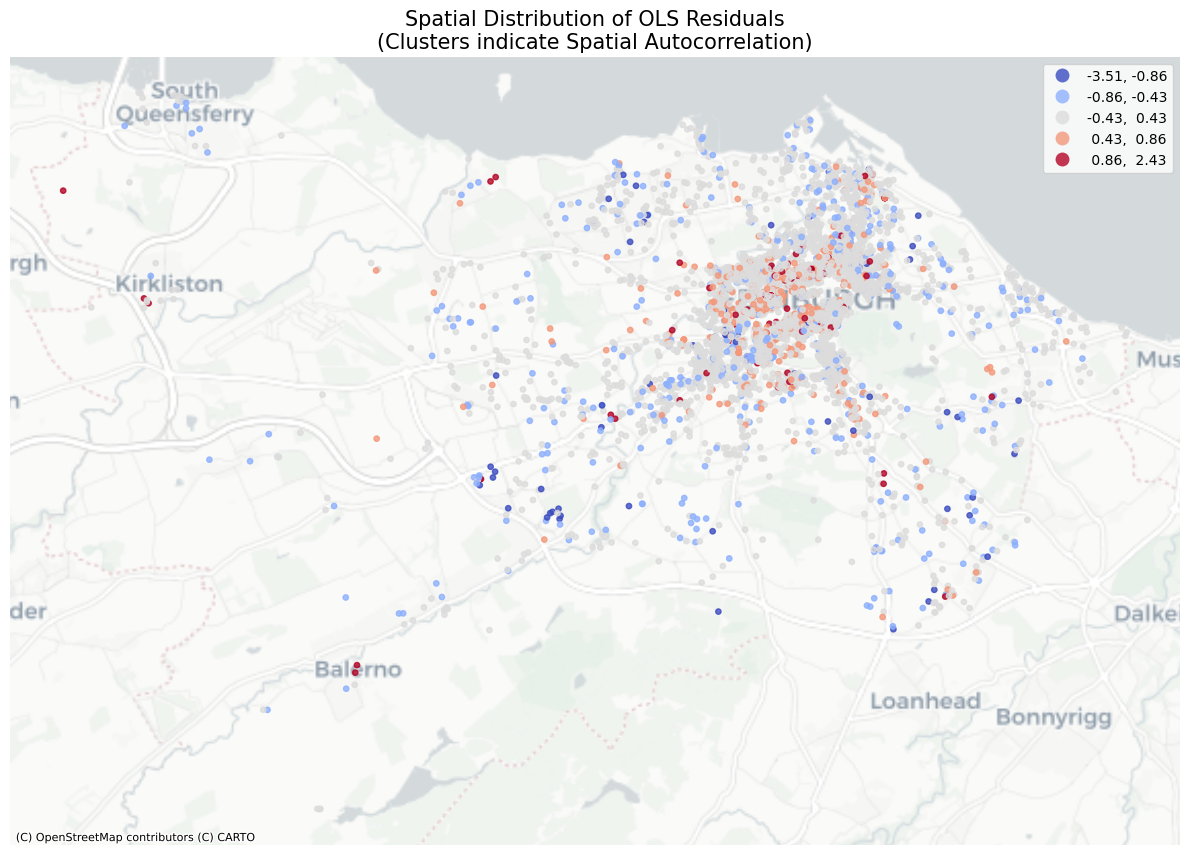

In [101]:
## Mapping residuals
df_clean['ols_residuals'] = ols.u
gdf_res = gpd.GeoDataFrame(
    df_clean, 
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude), 
    crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(12, 10))
gdf_res_proj = gdf_res.to_crs(epsg=3857)
gdf_res_proj.plot(
    column='ols_residuals', 
    scheme='std_mean', # Standard deviation from mean highlights outliers well
    k=5, 
    cmap='coolwarm',   # Red = High/Positive, Blue = Low/Negative
    legend=True, 
    ax=ax, 
    markersize=15, 
    alpha=0.8)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title('Spatial Distribution of OLS Residuals\n(Clusters indicate Spatial Autocorrelation)', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [100]:
## Moran's I test
residuals = ols.u.flatten()
moran = Moran(residuals, w_knn)
print("=== Global Moran's I Test on OLS Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

=== Global Moran's I Test on OLS Residuals ===
Moran's I:     0.3006
Expected I:    -0.0002
Z-score:       52.5344
P-value:       0.0010



In [ ]:
## SEM model
sem = ML_Error(
    y, x,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb (SEM)'
)
print(sem.summary)

In [ ]:
## SEM model residual map
gdf_web['sem_resid'] = sem.u
target_column = 'sem_resid'
fig, ax = plt.subplots(figsize=(12, 10))
gdf_web.plot(
    column=target_column, 
    cmap='coolwarm',      
    scheme='quantiles',    
    k=5,                   
    markersize=5, 
    legend=True, 
    ax=ax, 
    alpha=0.7
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Residual Map: {target_column}', fontsize=15)
plt.show()

In [ ]:
## Moran's I SEM
residuals = sem.u.flatten()
moran = Moran(residuals, w_knn)
print("=== Global Moran's I Test on SEM Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

In [102]:
## SAR model
sar = ML_Lag(
    y, x,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb (SAR)'
)
print(sar.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Edinburgh Airbnb (SAR)
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4407
Mean dependent var  :      5.0609                Number of Variables   :          12
S.D. dependent var  :      0.6107                Degrees of Freedom    :        4395
Pseudo R-squared    :      0.6061
Spatial Pseudo R-squared:  0.4879
Log likelihood      :  -2080.1328
Sigma-square ML     :      0.1470                Akaike info criterion :    4184.266
S.E of regression   :      0.3834                Schwarz criterion     :    4260.957

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------

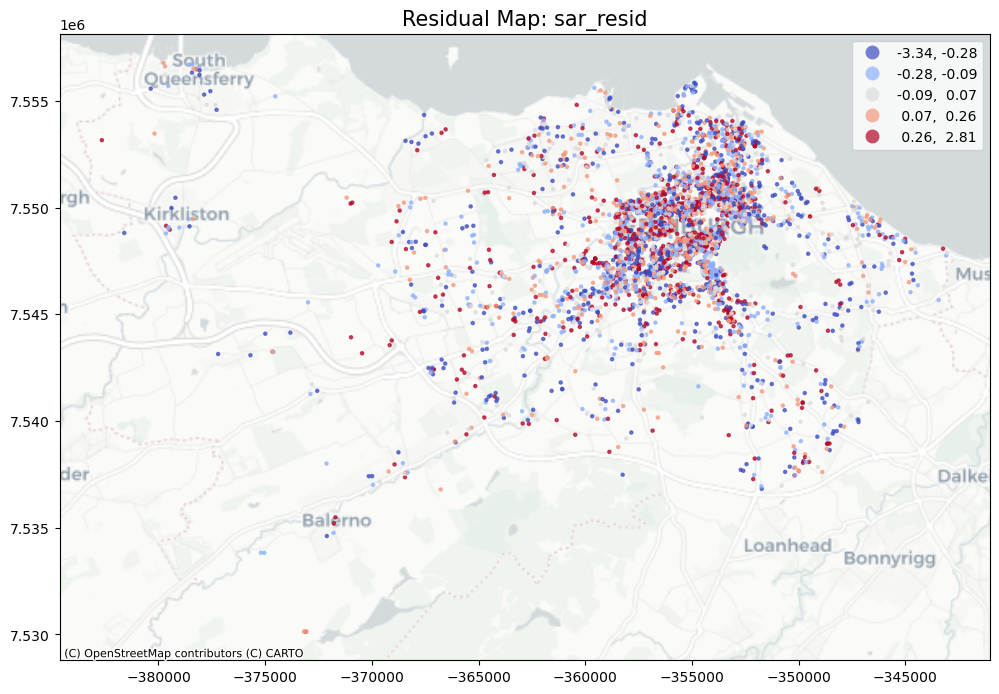

In [103]:
## SAR model residual map
gdf_web['sar_resid'] = sar.u
target_column = 'sar_resid'
fig, ax = plt.subplots(figsize=(12, 10))
gdf_web.plot(
    column=target_column,
    cmap='coolwarm',
    scheme='quantiles',    
    k=5,                   
    markersize=5, 
    legend=True, 
    ax=ax, 
    alpha=0.7
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Residual Map: {target_column}', fontsize=15)
plt.show()

In [104]:
# Moran's I SAR
residuals = sar.u.flatten()
moran = Moran(residuals, w_knn)
print("=== Global Moran's I Test on SAR Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

=== Global Moran's I Test on SAR Residuals ===
Moran's I:     0.0448
Expected I:    -0.0002
Z-score:       7.9192
P-value:       0.0010



In [105]:
## SDM model
wx_cols = ['W_' + col for col in x_cols]
wx_array = np.column_stack([lag_spatial(w_knn, x[:, i]) for i in range(x.shape[1])])
x_sdm = np.hstack([x, wx_array])
x_sdm_names = x_cols + wx_cols
sdm = ML_Lag(
    y, x_sdm,
    w=w_knn,
    name_y=y_col,
    name_x=x_sdm_names,
    name_ds='Edinburgh Airbnb (SDM)'
)
print(sdm.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Edinburgh Airbnb (SDM)
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4407
Mean dependent var  :      5.0609                Number of Variables   :          22
S.D. dependent var  :      0.6107                Degrees of Freedom    :        4385
Pseudo R-squared    :      0.6260
Spatial Pseudo R-squared:  0.5510
Log likelihood      :  -1980.8370
Sigma-square ML     :      0.1396                Akaike info criterion :    4005.674
S.E of regression   :      0.3736                Schwarz criterion     :    4146.275

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------

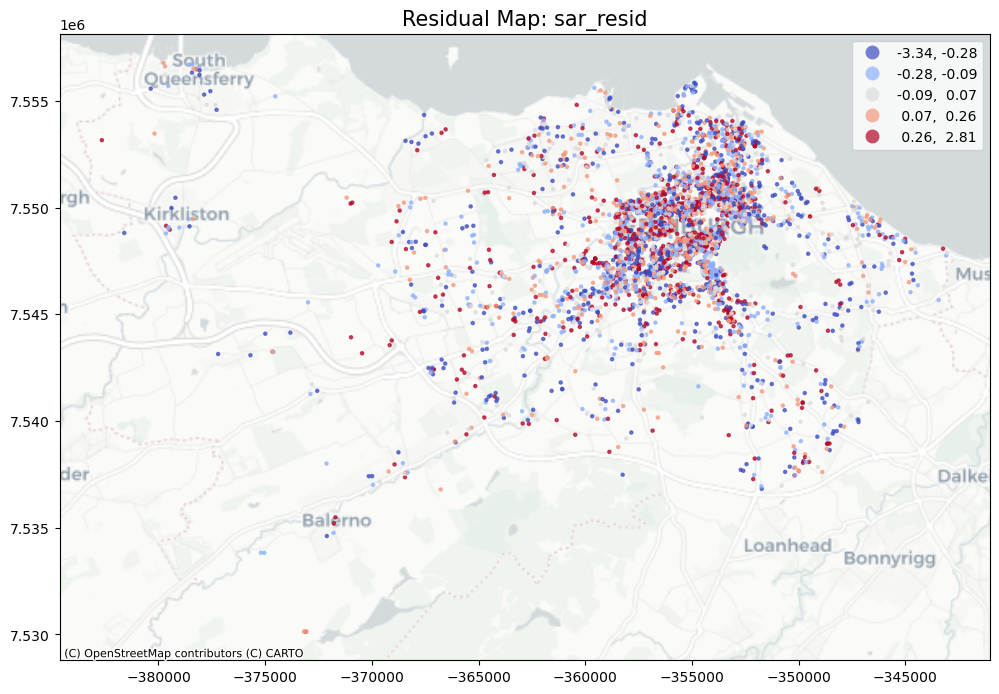

In [106]:
## SDM model residual map
gdf_web['sdm_resid'] = sdm.u
fig, ax = plt.subplots(figsize=(12, 10))
gdf_web.plot(
    column=target_column, 
    cmap='coolwarm',       
    scheme='quantiles',    
    k=5,                  
    markersize=5, 
    legend=True, 
    ax=ax, 
    alpha=0.7
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Residual Map: {target_column}', fontsize=15)
plt.show()

In [107]:
## Moran's I SDM
residuals = sdm.u.flatten()
moran = Moran(residuals, w_knn)
print("=== Global Moran's I Test on SDM Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

=== Global Moran's I Test on SDM Residuals ===
Moran's I:     -0.0080
Expected I:    -0.0002
Z-score:       -1.3582
P-value:       0.0910

